# Experiment 5: Impact of Artificial Image Distortions on Caption Quality

Evaluate the robustness of the visual feature extractor (ResNet-101) against standard image degradations: Gaussian noise, blur, and contrast changes.

In [12]:
import json
import torch
import os
import sys
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from PIL import Image
from contextlib import contextmanager

# Setup
sys.path.insert(0, os.path.abspath('..'))
from caption import caption_image_beam_search
import models  # Import models so pickle can find Encoder/Decoder classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'
WORDMAP_PATH = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
DATASET_PATH = '../dataset/caption_datasets/dataset_coco.json'

# Workaround for Adam optimizer unpickling issue
@contextmanager
def patch_torch_optim():
    """Temporarily patch torch.optim classes to skip problematic state deserialization."""
    original_setstate = {}
    try:
        # Create a no-op __setstate__ that prevents the attribute error
        def noop_setstate(self, state):
            pass
        
        # Save original and patch
        original_setstate['Adam'] = torch.optim.Adam.__setstate__
        original_setstate['SGD'] = torch.optim.SGD.__setstate__
        torch.optim.Adam.__setstate__ = noop_setstate
        torch.optim.SGD.__setstate__ = noop_setstate
        
        yield
    finally:
        # Restore
        for name, method in original_setstate.items():
            getattr(torch.optim, name).__setstate__ = method

# Load model with optimizer patching
with patch_torch_optim():
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=str(device), weights_only=True)
    except Exception:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=str(device), weights_only=False)

decoder = checkpoint['decoder'].to(device).eval()
encoder = checkpoint['encoder'].to(device).eval()

with open(WORDMAP_PATH, 'r') as f:
    word_map = json.load(f)
rev_word_map = {v: k for k, v in word_map.items()}

with open(DATASET_PATH, 'r') as f:
    dataset = json.load(f)

# Build references
references = {}
for img in dataset['images']:
    if img['split'] in {'val', 'test'}:
        references[img['filename']] = [[token for token in sent['tokens']] for sent in img['sentences']]

print("Model and data loaded")

Model and data loaded


In [13]:
def apply_distortions(image_path):
    """Apply various distortions and return distorted versions."""
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    distortions = {}
    
    # Original (baseline)
    distortions['original'] = img_rgb.copy()
    
    # Gaussian noise (low, medium, high)
    for sigma in [10, 25, 50]:
        noise = np.random.normal(0, sigma, img_rgb.shape).astype(np.uint8)
        distortions[f'noise_σ={sigma}'] = np.clip(img_rgb.astype(int) + noise, 0, 255).astype(np.uint8)
    
    # Motion blur
    for kernel_size in [5, 15, 25]:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
        distortions[f'blur_k={kernel_size}'] = cv2.filter2D(img_rgb, -1, kernel / kernel.sum())
    
    # Contrast reduction
    for alpha in [0.3, 0.6, 0.9]:
        distortions[f'contrast_α={alpha}'] = (alpha * img_rgb).astype(np.uint8)
    
    return distortions

# Test on a subset
num_test = 30
test_files = list(references.keys())[:num_test]
results = []

print(f"Processing {num_test} test images with distortions...")

with torch.no_grad():
    for idx, filename in enumerate(test_files):
        if (idx + 1) % 10 == 0:
            print(f"  Processed {idx + 1}/{num_test}")
        
        fpath = os.path.join('../dataset/val2014', filename)
        if not os.path.exists(fpath):
            continue
        
        try:
            distorted_imgs = apply_distortions(fpath)
            ref_captions = references[filename]
            
            entry = {'filename': filename}
            
            for distortion_name, dist_img in distorted_imgs.items():
                # Save temporarily
                temp_path = f'/tmp/distorted_{distortion_name}.jpg'
                cv2.imwrite(temp_path, cv2.cvtColor(dist_img.astype(np.uint8), cv2.COLOR_RGB2BGR))
                
                # Generate caption
                seq, _ = caption_image_beam_search(encoder, decoder, temp_path, word_map, 5)
                hyp = [rev_word_map[i] for i in seq if i not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
                
                # Compute BLEU
                smoother = SmoothingFunction().method1
                bleu = sentence_bleu(ref_captions, hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother)
                entry[f'bleu_{distortion_name}'] = bleu
                
                os.remove(temp_path)
            
            results.append(entry)
        except Exception as e:
            continue

df_distortions = pd.DataFrame(results)
print(f"Completed distortion experiment on {len(df_distortions)} images")

Processing 30 test images with distortions...
  Processed 10/30
  Processed 20/30
  Processed 30/30
Completed distortion experiment on 30 images



=== Distortion Impact on BLEU-4 ===
Baseline (original): 0.2881
blur_k=15           : 0.2327 (↓ 19.2%)
blur_k=25           : 0.0987 (↓ 65.7%)
blur_k=5            : 0.2605 (↓ 9.6%)
contrast_α=0.3      : 0.3168 (↓ -10.0%)
contrast_α=0.6      : 0.2970 (↓ -3.1%)
contrast_α=0.9      : 0.2927 (↓ -1.6%)
noise_σ=10          : 0.1328 (↓ 53.9%)
noise_σ=25          : 0.1338 (↓ 53.5%)
noise_σ=50          : 0.1228 (↓ 57.4%)


/tmp/ipykernel_9590/3980509938.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_for_box, labels=labels_for_box)


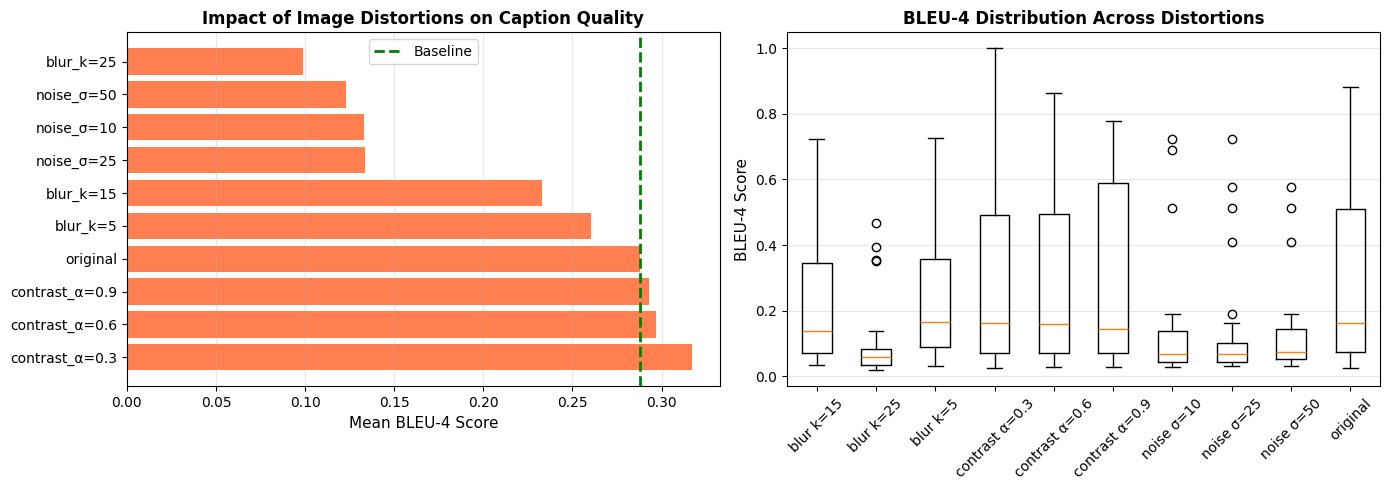

In [14]:
# Analyze results
bleu_cols = [c for c in df_distortions.columns if c.startswith('bleu_')]
baseline_bleu = df_distortions['bleu_original'].mean()

print("\n=== Distortion Impact on BLEU-4 ===")
print(f"Baseline (original): {baseline_bleu:.4f}")

for col in sorted([c for c in bleu_cols if c != 'bleu_original']):
    distortion_name = col.replace('bleu_', '')
    mean_bleu = df_distortions[col].mean()
    degradation = ((baseline_bleu - mean_bleu) / baseline_bleu) * 100
    print(f"{distortion_name:20s}: {mean_bleu:.4f} (↓ {degradation:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean BLEU by distortion type
distortion_summary = {}
for col in bleu_cols:
    name = col.replace('bleu_', '')
    distortion_summary[name] = df_distortions[col].mean()

df_summary = pd.DataFrame(list(distortion_summary.items()), columns=['Distortion', 'Mean BLEU-4'])
df_summary = df_summary.sort_values('Mean BLEU-4', ascending=False)

axes[0].barh(df_summary['Distortion'], df_summary['Mean BLEU-4'], color='coral')
axes[0].axvline(baseline_bleu, color='green', linestyle='--', linewidth=2, label='Baseline')
axes[0].set_xlabel('Mean BLEU-4 Score', fontsize=11)
axes[0].set_title('Impact of Image Distortions on Caption Quality', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Box plot of BLEU distributions
data_for_box = []
labels_for_box = []
for col in sorted(bleu_cols):
    data_for_box.append(df_distortions[col].values)
    labels_for_box.append(col.replace('bleu_', '').replace('_', ' '))

axes[1].boxplot(data_for_box, labels=labels_for_box)
axes[1].set_ylabel('BLEU-4 Score', fontsize=11)
axes[1].set_title('BLEU-4 Distribution Across Distortions', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()